### **Gradient Descent: Predicting Car Prices**

#### Objective:
Your task is to implement and use **Gradient Descent** to optimize a regression model for predicting car prices based on various features. You'll work with a real-world dataset to understand the workings of gradient descent, evaluate its performance, and compare it with other optimization techniques.


#### Dataset:
Use the **Car Price Prediction Dataset**: `data/car_price.csv`, which contains information on car features and their respective prices. Each row corresponds to a car, and the columns represent various features such as horsepower, engine size, and car dimensions. The target variable is the **car price (in dollars)**.


#### Steps to Complete:

1. **Data Loading and Exploration**  
   - Load the dataset using `pandas`.
   - Display the first few rows and explore the dataset to understand the features and their distributions.
   - Check for missing values and handle them appropriately.
   - Normalize or scale the features to ensure smooth convergence of gradient descent.

2. **Define the Linear Regression Model**  
   - Create a linear regression model with parameters (weights and biases) initialized to zero or small random values.
   - Define the **cost function** as **Mean Squared Error (MSE)**.

3. **Implement Gradient Descent**  
   - Write a custom implementation of Gradient Descent to optimize the weights and biases of the regression model:
     - Compute gradients of the cost function with respect to each parameter.
     - Update parameters iteratively using the gradient descent formula:
       $$
       \theta := \theta - \alpha \cdot \nabla J(\theta)
       $$
       where $ \alpha $ is the learning rate.

4. **Experiment with Hyperparameters**  
   - Test the algorithm with different learning rates ($ \alpha $).
   - Observe and plot the cost function values over iterations to ensure convergence.

5. **Model Evaluation**  
   - Split the dataset into **training** and **test sets**.
   - Evaluate the model's performance on both datasets using:
     - Mean Squared Error (MSE)
     - R² score
   - Compare predictions with actual values.

6. **Visualization**  
   - Plot the cost function against iterations to visualize convergence.
   - Visualize the relationship between key features (e.g., Horsepower) and predicted car prices.


#### Bonus Challenges (Optional):

1. **Mini-Batch Gradient Descent**:  
   - Modify your implementation to use mini-batches instead of the entire dataset for each gradient step.
   - Compare the performance and convergence speed of batch and mini-batch gradient descent.

2. **Stochastic Gradient Descent (SGD)**:  
   - Implement stochastic gradient descent and compare its performance with batch gradient descent.

3. **Multiple Models**:  
   - Train and evaluate the same dataset using **Scikit-learn's LinearRegression** for comparison.

4. **Polynomial Features**:  
   - Add polynomial terms for key features (e.g., horsepower squared) to improve model performance and evaluate the impact of feature engineering.


#### Deliverables:
- A Python script or Jupyter Notebook containing:
  - Code for loading and preprocessing the data.
  - Implementation of Gradient Descent for linear regression.
  - Results of model training and evaluation.
  - Visualizations of cost function convergence and predictions.
- A brief report answering:
  - How does the learning rate affect convergence?
  - What were the final MSE and R² scores?
  - Insights from comparing different optimization techniques.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.linear_model import LinearRegression

In [2]:
df = pd.read_csv("data/car_price.csv")

df.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [ ]:
df.info()
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


In [6]:
df['Company'] = df['CarName'].apply(lambda x: x.split()[0].lower())

df.drop(columns=['car_ID', 'CarName'], inplace=True)

In [8]:
df['Company'].value_counts()

Company
toyota         31
nissan         18
mazda          15
honda          13
mitsubishi     13
subaru         12
peugeot        11
volvo          11
volkswagen      9
dodge           9
bmw             8
buick           8
audi            7
plymouth        7
saab            6
isuzu           4
porsche         4
chevrolet       3
alfa-romero     3
jaguar          3
maxda           2
renault         2
vw              2
porcshce        1
mercury         1
toyouta         1
vokswagen       1
Name: count, dtype: int64

In [9]:
brand_corrections = {
    'vw': 'volkswagen',
    'vokswagen': 'volkswagen',
    'porcshce': 'porsche',
    'toyouta': 'toyota',
    'maxda': 'mazda',
}

df['Company'] = df['Company'].replace(brand_corrections)

In [10]:
df = df[['symboling', 'fueltype', 'aspiration', 'doornumber', 'carbody', 'drivewheel', 
         'enginelocation', 'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight', 
         'enginetype', 'cylindernumber', 'enginesize', 'fuelsystem', 'boreratio', 
         'stroke', 'compressionratio', 'horsepower', 'peakrpm', 'citympg', 
         'highwaympg', 'price']]


In [11]:
X = df.drop(['price'], axis=1)
y = df['price']

In [12]:
categorical_cols = ['fueltype', 'aspiration', 'doornumber', 'carbody', 
                    'drivewheel', 'enginelocation', 'enginetype', 
                    'cylindernumber', 'fuelsystem']


X_cat = df[categorical_cols]
X_num = df.drop(columns=categorical_cols + ['price'])

ohe = OneHotEncoder(drop='first', sparse_output=False)
X_cat_encoded = ohe.fit_transform(X_cat)

encoded_cols = ohe.get_feature_names_out(categorical_cols)

X_encoded = pd.DataFrame(X_cat_encoded, columns=encoded_cols, index=df.index)

X_final = pd.concat([X_encoded, X_num], axis=1)
y = df['price']

In [14]:
X_train, X_test, y_train, y_test = train_test_split(X_final, y, test_size=0.2, random_state=42)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


In [15]:
model = LinearRegression()
model.fit(X_scaled, y_train)

LinearRegression()

In [16]:
from sklearn.metrics import mean_squared_error, r2_score

y_pred = model.predict(X_test_scaled)

mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print(f"MSE: {mse:.2f}")
print(f"R^2 score: {r2:.4f}")


MSE: 8482008.48
R^2 score: 0.8926


### **Custom linear regression**

In [17]:
class CustomLinearRegression:
    def __init__(self, learning_rate=0.01, max_iter=1000, tolerance=0.0001):
        self.lr = learning_rate
        self.max_iter = max_iter
        self.tolerance = tolerance
        self.loss_history = []

    def fit(self, X, y):
        X = np.asarray(X)
        y = np.asarray(y)
        X = np.c_[np.ones(X.shape[0]), X]  
        self.theta = np.zeros(X.shape[1])
        m = X.shape[0]

        prev_loss = float('inf')

        for i in range(self.max_iter):
            y_pred = X.dot(self.theta)
            error = y_pred - y
            gradient = (1/m) * X.T.dot(error)
            self.theta -= self.lr * gradient

            loss = (1/(2*m)) * np.sum(error ** 2)
            self.loss_history.append(loss)

            if abs(prev_loss - loss) < self.tolerance:
                print(f"Converged at iteration {i}")
                break

            prev_loss = loss

    def predict(self, X):
        X = np.asarray(X)
        X = np.c_[np.ones(X.shape[0]), X]
        return X.dot(self.theta)


In [18]:
model = CustomLinearRegression(learning_rate=0.2, max_iter=1000, tolerance=0.0001)
model.fit(X_scaled, y_train)

# Prediction
y_pred_train = model.predict(X_scaled)
y_pred_test = model.predict(X_test_scaled)

train_mse = mean_squared_error(y_train, y_pred_train)
test_mse = mean_squared_error(y_test, y_pred_test)

train_r2 = r2_score(y_train, y_pred_train)
test_r2 = r2_score(y_test, y_pred_test)

# Results
print("Train MSE:", train_mse)
print("Test MSE:", test_mse)
print("Train R^2:", train_r2)
print("Test R^2:", test_r2)


Train MSE: 3124104.2869601524
Test MSE: 8600815.829722302
Train R^2: 0.947615399486413
Test R^2: 0.8910517131774502


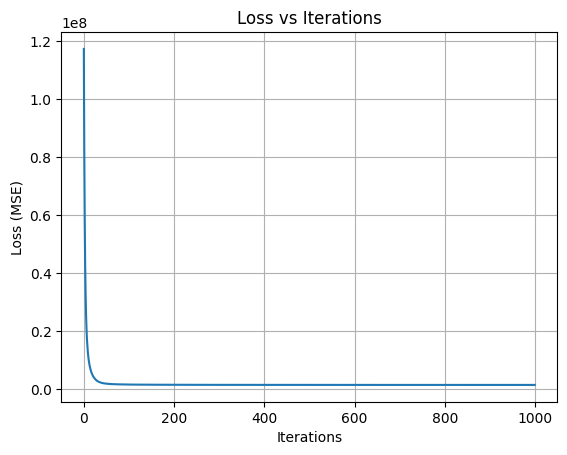

In [19]:
import matplotlib.pyplot as plt

plt.plot(model.loss_history)
plt.xlabel("Iterations")
plt.ylabel("Loss (MSE)")
plt.title("Loss vs Iterations")
plt.grid(True)
plt.show()


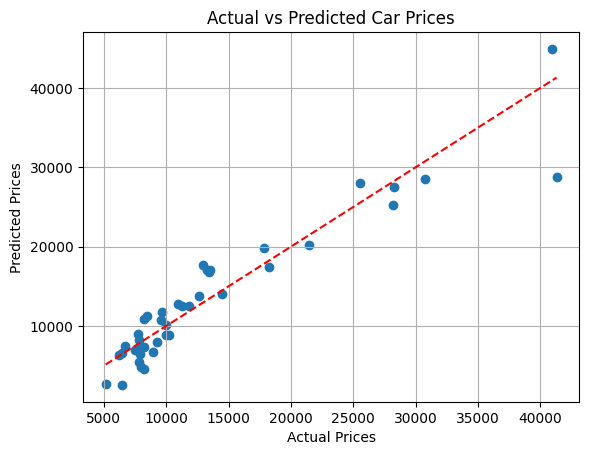

In [20]:
plt.scatter(y_test, y_pred_test)
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted Car Prices")
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--')
plt.grid(True)
plt.show()
